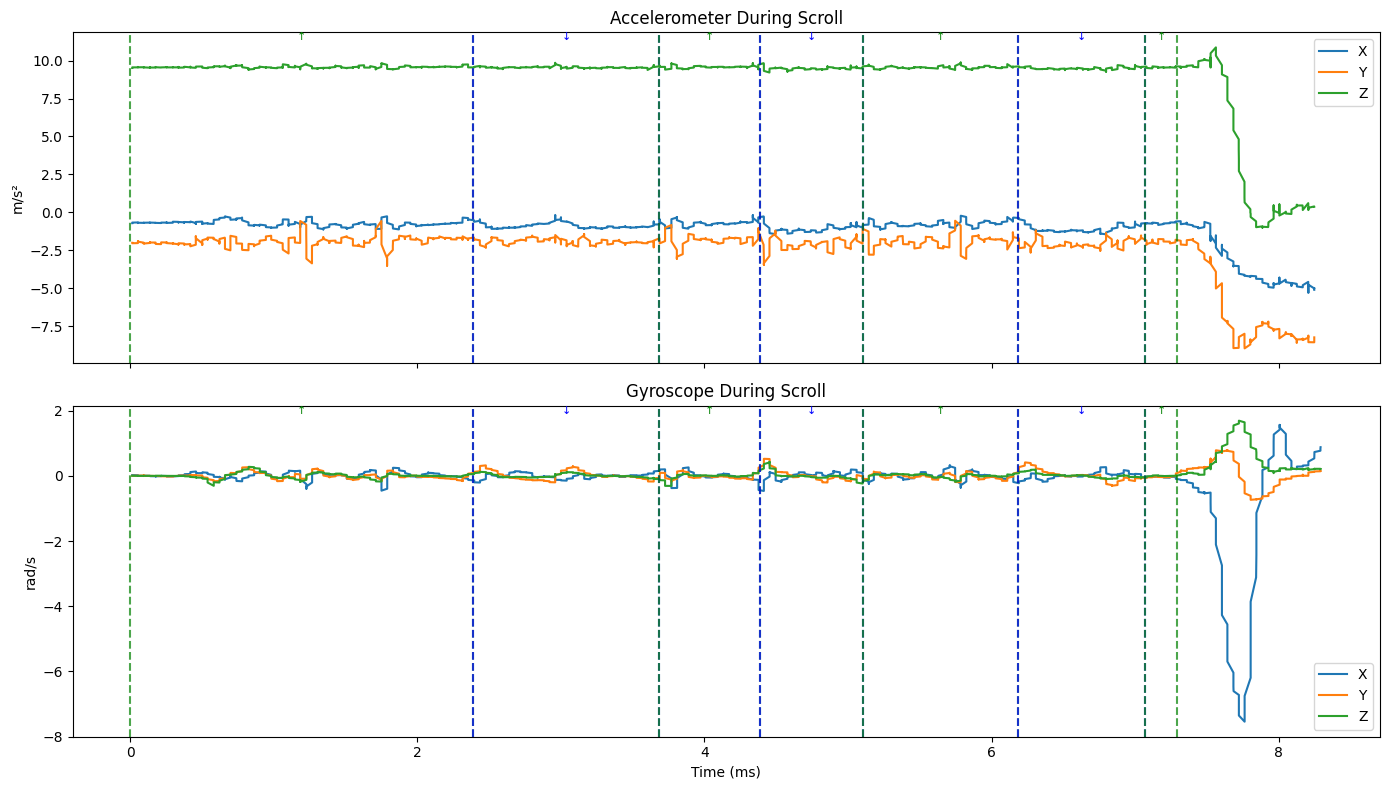

In [ ]:
#this is the new and improved way to will hopefully work
import pandas as pd, os
import matplotlib.pyplot as plt
from DBConfig import DB_HOST, DB_NAME, DB_PASSWORD, DB_PORT, DB_USER, psycopg2



# Get session data
session_id = "29"
conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)
cursor = conn.cursor()

# Step 2: Query the session data - ONLY SELECTING USED COLUMNS
session_query = """
SELECT "ID", "DataFileName", "StartScrollingID", "EndScrollingID"
FROM "Sessions"
WHERE "ID" = %s
"""
cursor.execute(session_query, (session_id,))
session_data = cursor.fetchone()

if not session_data:
    raise ValueError(f"Session with ID {session_id} not found.")

# Unpack only the 4 columns retrieved
session_id, data_file_name, start_scroll_id, end_scroll_id = session_data

print(f"Session Data (partial): {session_data}")

# Load sensor data (assuming data_file_name points to the CSV)
df = pd.read_csv(data_file_name, header=None, 
                names=['sensor_type', 'timestamp', 'nanoTimestamp', 'x', 'y', 'z'])

# Step 3: Query the scrolling data for the session
scroll_query = """
SELECT "StartTimestamp", "EndTimestamp", "Direction", "ID", "DataFileName"
FROM "Scrolling"
WHERE "ID" BETWEEN %s AND %s
ORDER BY "StartTimestamp"
"""
cursor.execute(scroll_query, (start_scroll_id, end_scroll_id,))
scrolls = cursor.fetchall()
scrollingDataPath = f"SessionsData/ScrollingData/"
# ---- Segment and save each scroll event ----
output_folder = f"{scrollingDataPath}session_{session_id}" # Using the ID retrieved from DB
os.makedirs(output_folder, exist_ok=True)


conn.close()



for start_ts, end_ts, direction, scroll_id in scrolls:
    segment = df[(df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)]
    segment.to_csv(f"{output_folder}/scroll_{scroll_id}.csv", index=False, header=False)


# ---- Visualization ----
start_time = min(df['timestamp'].min(), min(s[0] for s in scrolls))
df['time_ms'] = (df['timestamp'] - start_time) / 1000.0
scrolls_ms = [((s - start_time) / 1000.0, (e - start_time) / 1000.0, d) for s, e, d, _ in scrolls]

accel_df = df[df['sensor_type'] == 10]
gyro_df = df[df['sensor_type'] == 4]

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Accelerometer
axs[0].plot(accel_df['time_ms'], accel_df['x'], label='X')
axs[0].plot(accel_df['time_ms'], accel_df['y'], label='Y')
axs[0].plot(accel_df['time_ms'], accel_df['z'], label='Z')
axs[0].set_title("Accelerometer During Scroll")
axs[0].set_ylabel("m/s²")
axs[0].legend()

# Gyroscope
axs[1].plot(gyro_df['time_ms'], gyro_df['x'], label='X')
axs[1].plot(gyro_df['time_ms'], gyro_df['y'], label='Y')
axs[1].plot(gyro_df['time_ms'], gyro_df['z'], label='Z')
axs[1].set_title("Gyroscope During Scroll")
axs[1].set_ylabel("rad/s")
axs[1].set_xlabel("Time (ms)")
axs[1].legend()

# Add scroll lines
for ax in axs:
    for start_ms, end_ms, direction in scrolls_ms:
        color = 'green' if direction == 1 else 'blue'
        label = "↑" if direction == 1 else "↓"
        ax.axvline(x=start_ms, color=color, linestyle='--', alpha=0.7)
        ax.axvline(x=end_ms, color=color, linestyle='--', alpha=0.7)
        ax.text((start_ms + end_ms) / 2, ax.get_ylim()[1], label,
                ha='center', va='top', fontsize=8, color=color)

plt.tight_layout()
plt.show()


In [6]:
scrolls

[(1749493130131, 1749493132517, 1, 13),
 (1749493132517, 1749493133817, 2, 14),
 (1749493133817, 1749493134517, 1, 15),
 (1749493134517, 1749493135233, 2, 16),
 (1749493135233, 1749493136317, 1, 17),
 (1749493136317, 1749493137200, 2, 18),
 (1749493137200, 1749493137425, 1, 19)]

[(1743635726093, 1743635727137, 1), (1743635727137, 1743635727868, 2), (1743635727868, 1743635728645, 1), (1743635728645, 1743635729670, 2), (1743635729670, 1743635730580, 1)]
2025-04-02 23:15:36.601000
Sensor duration: 9.49s
Total scroll duration: 8.35s
Time shift applied: 1.16s


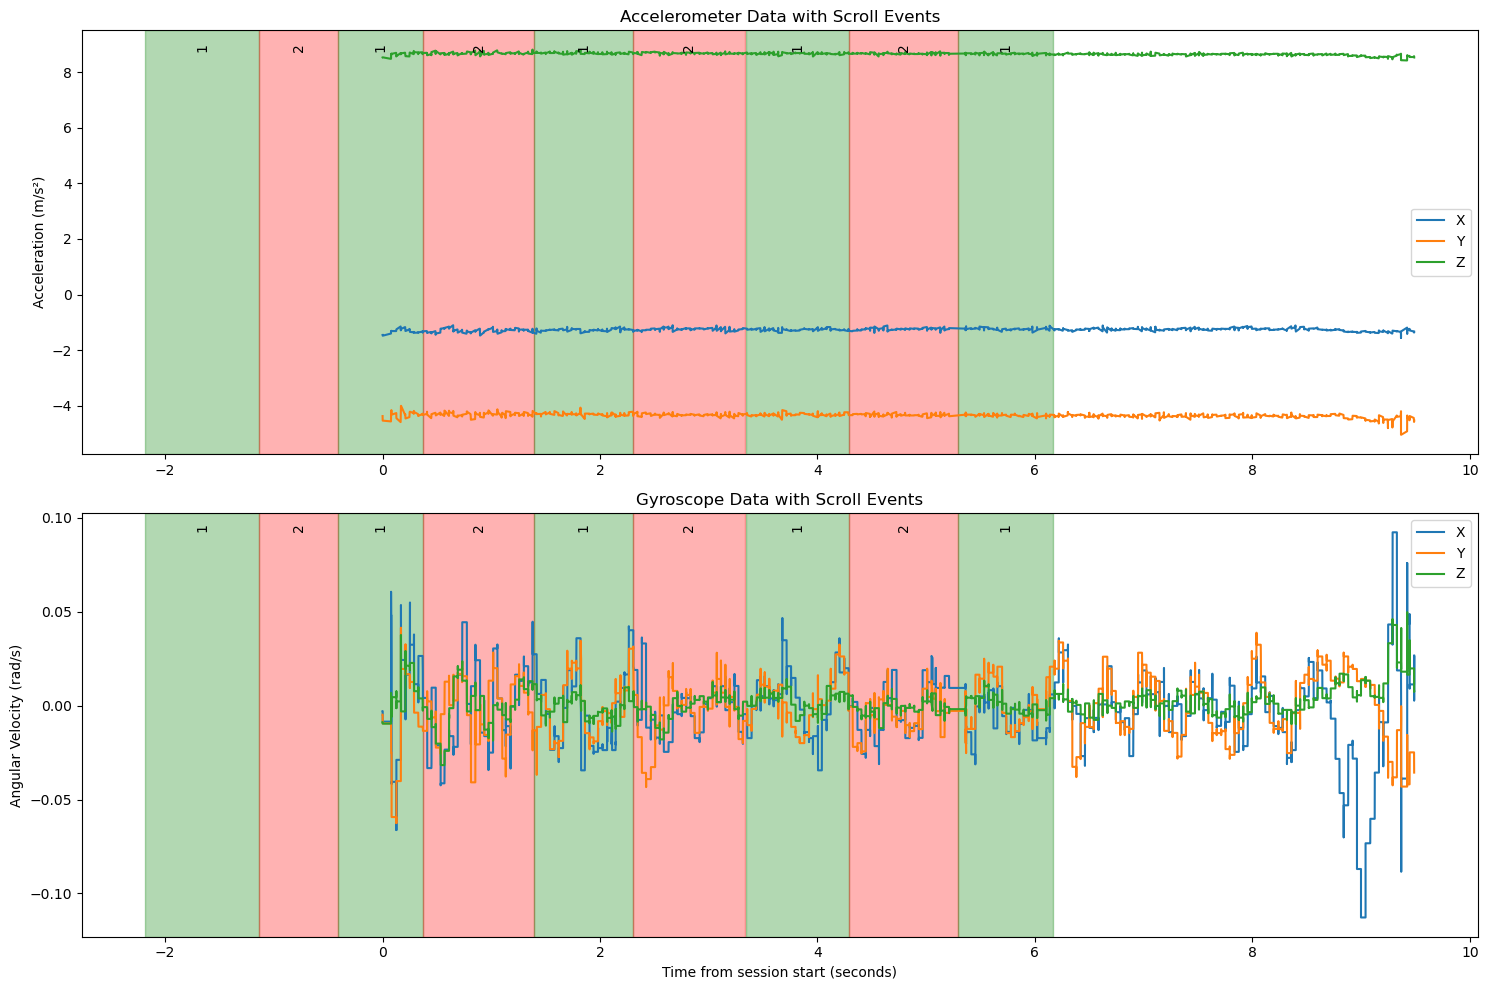

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Database connection and data loading
db_path = "DataCollection.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Get session data
session_id = "98"
session_query = """SELECT ID, StartTimestamp, EndTimestamp, DataFileName, 
                    Processed, SessionType, userID, StartScrollingID, EndScrollingID 
                    FROM Sessions WHERE ID = ?"""
cursor.execute(session_query, (session_id,))
session_data = cursor.fetchone()

if not session_data:
    raise ValueError(f"Session with ID {session_id} not found.")

session_id, start_timestamp, end_timestamp, data_file_name, processed, \
session_type, user_id, start_scroll_id, end_scroll_id = session_data
scroll_query = """
SELECT StartTimestamp, ENDTimestamp, Direction
FROM Scrolling
WHERE ID between ? and ?
ORDER BY StartTimestamp
"""
cursor.execute(scroll_query, (start_scroll_id, end_scroll_id,))
scrolls = cursor.fetchall()

conn.close()

# Load sensor data
df = pd.read_csv(data_file_name, header=None, 
                 names=['sensor_type', 'timestamp', 'nanoTimestamp', 'x', 'y', 'z'])
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Get scroll data

# scrolls = [(s[0], s[1], 'Up' if s[2] == 1 else 'Down') for s in scrolls]  # Convert direction to text
print(scrolls[:5])
# Convert timestamps
session_start = pd.to_datetime(start_timestamp, unit='ms')
session_end = pd.to_datetime(end_timestamp, unit='ms')
sensorDuration = df['rel_time'].iloc[-1] - df['rel_time'].iloc[0]
sensor_start = df['datetime'].iloc[0]
sensor_end = df['datetime'].iloc[-1]

# Calculate time shift based on 1-second gap
last_scroll_end = pd.to_datetime(scrolls[-1][1], unit='ms')
expected_end = sensor_end - pd.Timedelta(seconds=1)
time_shift = expected_end - last_scroll_end

# Process scrolls with alignment
scrolls_adj = []
for start, end, direction in scrolls:
    start_dt = pd.to_datetime(start, unit='ms') - time_shift
    end_dt = pd.to_datetime(end, unit='ms') - time_shift
    start_rel = (start_dt - sensor_start).total_seconds()
    end_rel = (end_dt - sensor_start).total_seconds()
    scrolls_adj.append((start_rel, end_rel, direction))

# Process sensor timestamps
df['rel_time'] = (df['datetime'] - sensor_start).dt.total_seconds()

# Verification
print(sensor_end)
print(f"Sensor duration: {df['rel_time'].iloc[-1] - df['rel_time'].iloc[0]:.2f}s")
print(f"Total scroll duration: {scrolls_adj[-1][1] - scrolls_adj[0][0]:.2f}s")
print(f"Time shift applied: {time_shift.total_seconds():.2f}s")

# Plotting
plt.figure(figsize=(15, 10))
colors = {1: 'green', 2: 'red'}

# Accelerometer plot
plt.subplot(2, 1, 1)
plt.plot(df['rel_time'], df[['accel_x', 'accel_y', 'accel_z']])
for start, end, direction in scrolls_adj:
    plt.axvspan(start, end, color=colors[direction], alpha=0.3)
    plt.text((start+end)/2, plt.ylim()[1]*0.95, direction, 
             ha='center', va='top', rotation=90)
plt.title('Accelerometer Data with Scroll Events')
plt.ylabel('Acceleration (m/s²)')
plt.legend(['X', 'Y', 'Z'])

# Gyroscope plot
plt.subplot(2, 1, 2)
plt.plot(df['rel_time'], df[['gyro_x', 'gyro_y', 'gyro_z']])
for start, end, direction in scrolls_adj:
    plt.axvspan(start, end, color=colors[direction], alpha=0.3)
    plt.text((start+end)/2, plt.ylim()[1]*0.95, direction, 
             ha='center', va='top', rotation=90)
plt.title('Gyroscope Data with Scroll Events')
plt.xlabel('Time from session start (seconds)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend(['X', 'Y', 'Z'])

plt.tight_layout()
plt.show()

0.22800000000000065
(255, 2.611999999999999, 3.2389999999999994, 2) 4.239


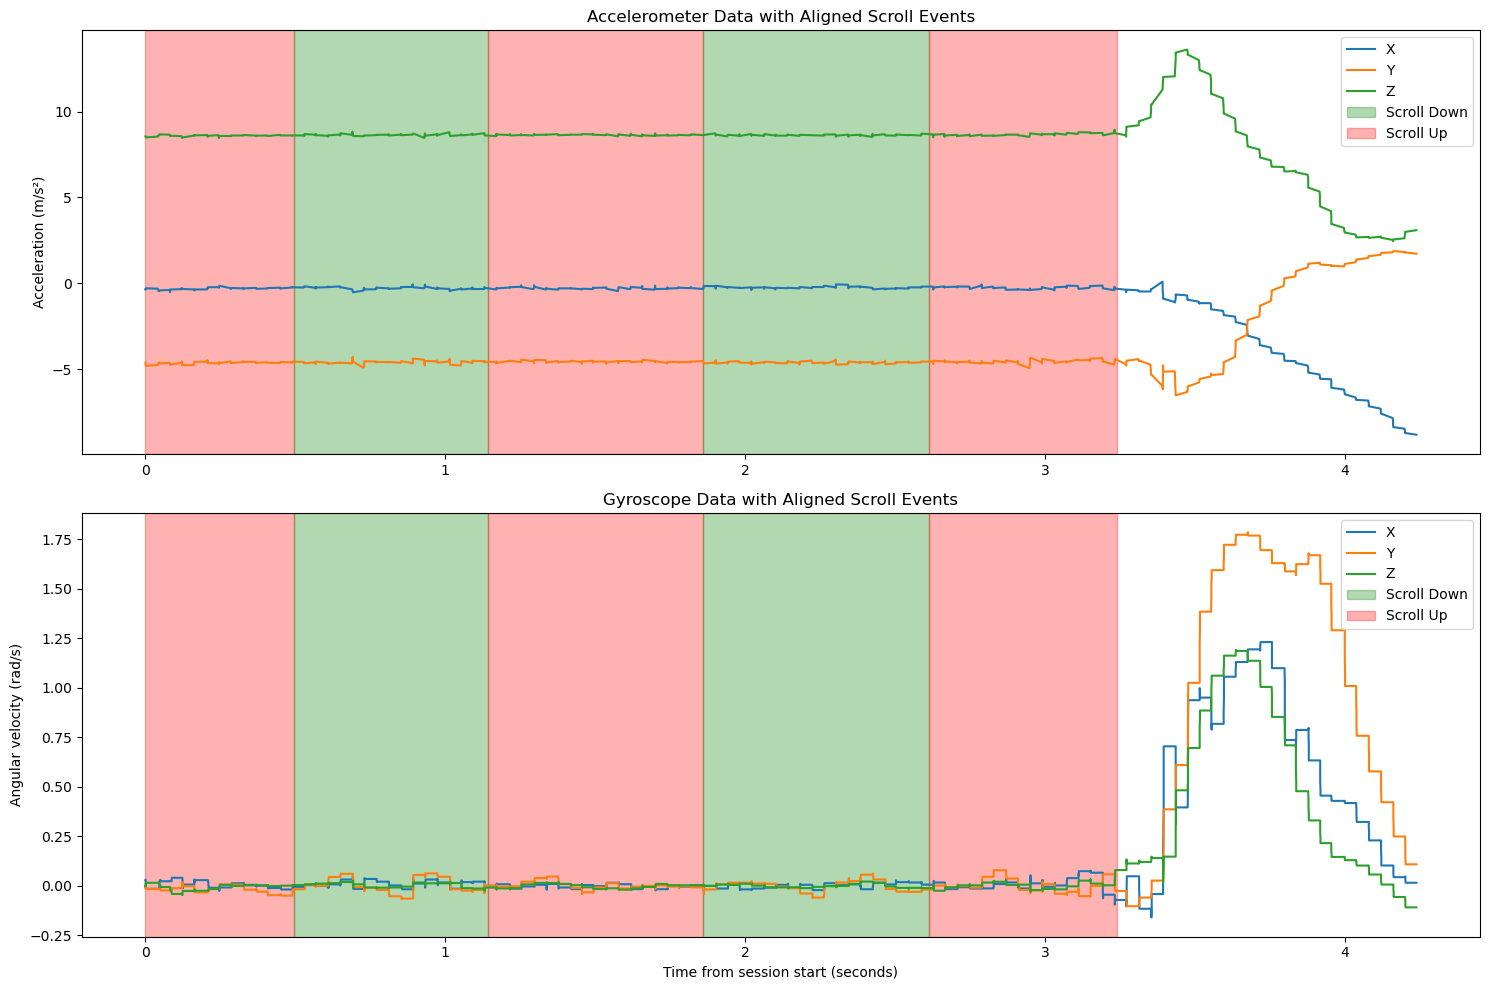

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3, uuid
import matplotlib.patches as mpatches  # Add this import

# Database connection
db_path = "DataCollection.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Get session data
session_id = "102"
cursor.execute("""
    SELECT StartTimestamp, EndTimestamp, DataFileName, StartKeyID, EndKeyID 
    FROM Sessions WHERE ID = ?""", (session_id,))
session_data = cursor.fetchone()
start_timestamp_db, end_timestamp_db, data_file_name, start_scroll_id, end_scroll_id = session_data

# Get scroll data
cursor.execute("""
    SELECT ID, StartTimestamp, ENDTimestamp, Direction 
    FROM Scrolling WHERE ID BETWEEN ? AND ? 
    ORDER BY StartTimestamp""", (start_scroll_id, end_scroll_id))
scrolls = cursor.fetchall()
conn.close()

# Load sensor data
df = pd.read_csv(data_file_name, header=None,
                 names=['timestamp', 'accel_x', 'accel_y', 'accel_z',
                        'gyro_x', 'gyro_y', 'gyro_z'])

# Convert all timestamps to datetime objects
session_start_db = pd.to_datetime(df.iloc[0]['timestamp'], unit='ms')
session_end_db = pd.to_datetime(df.iloc[1]['timestamp'], unit='ms')

# Convert scroll timestamps (database time system)
scrolls_datetime = [
    (s[0],
    pd.to_datetime(s[1], unit='ms'),
    pd.to_datetime(s[2], unit='ms'),
    s[3]
) for s in scrolls]

# Convert sensor timestamps (sensor time system)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
sensor_start = df['datetime'].iloc[0]
sensor_end = df['datetime'].iloc[-1]

# Calculate alignment parameters
first_scroll_start_db = scrolls_datetime[0][1]
last_scroll_end_db = scrolls_datetime[-1][2]

# Expected sensor duration based on scrolls + 1 second
expected_duration = (last_scroll_end_db - first_scroll_start_db).total_seconds() + 1
actual_duration = (sensor_end - sensor_start).total_seconds()
time_shift = expected_duration - actual_duration
print(time_shift)



# Calculate relative time scales
df['rel_time'] = (df['datetime'] - sensor_start).dt.total_seconds()


conn = sqlite3.connect(db_path)
cursor = conn.cursor()
# Convert scrolls to sensor-relative time
scrolls_relative = []
for scroll_id, start_db, end_db, direction in scrolls_datetime:
    # Calculate time since first scroll start (database time)
    scroll_start_rel = (start_db - first_scroll_start_db ).total_seconds() - time_shift
    scroll_end_rel = (end_db - first_scroll_start_db ).total_seconds() - time_shift
    if scroll_start_rel < 0:
        scroll_start_rel = 0

    if scroll_end_rel < 0:
        scroll_end_rel = 0
    
    if scroll_end_rel == 0 and scroll_start_rel == 0:
        continue


    # Filter sensor data
    mask = (df['rel_time'] >= scroll_start_rel) & (df['rel_time'] <= scroll_end_rel)
    scroll_data = df[mask]
    
    if scroll_data.empty:
        print(f"No data found for scroll {scroll_id}")
        continue
    
    # Save to file
    # filename = f"scroll_{scroll_id}_{str(uuid.uuid4())}_data.csv"
    # scroll_data.to_csv(filename, index=False)
    
    # # Update database
    # cursor.execute("""
    #     UPDATE Scrolling 
    #     SET DataFileName = ? 
    #     WHERE ID = ?""", (filename, scroll_id))
    # print(f"Saved scroll {scroll_id} data to {filename}")
    
    scrolls_relative.append((scroll_id, scroll_start_rel, scroll_end_rel, direction))


# Commit and close
conn.commit()
conn.close()
print(scrolls_relative[-1], df['rel_time'].iloc[-1])

# Visualization
plt.figure(figsize=(15, 10))
colors = {1: 'green', 2: 'red'}
# Create legend patches for scroll directions
scroll_patches = [
    mpatches.Patch(color='green', alpha=0.3, label='Scroll Down'),
    mpatches.Patch(color='red', alpha=0.3, label='Scroll Up')
]



# Accelerometer plot
plt.subplot(2, 1, 1)
plt.plot(df['rel_time'], df['accel_x'], label='X')
plt.plot(df['rel_time'], df['accel_y'], label='Y')
plt.plot(df['rel_time'], df['accel_z'], label='Z')

for id , start, end, dir in scrolls_relative:
    plt.axvspan(start, end, color=colors[dir], alpha=0.3)
    plt.text((start+end)/2, plt.ylim()[1]*0.95, "")

plt.title('Accelerometer Data with Aligned Scroll Events')
plt.ylabel('Acceleration (m/s²)')

# Get existing handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Combine sensor labels with scroll direction patches
all_handles = handles + scroll_patches
plt.legend(handles=handles + scroll_patches)

# Gyroscope plot
plt.subplot(2, 1, 2)
plt.plot(df['rel_time'], df['gyro_x'], label='X')
plt.plot(df['rel_time'], df['gyro_y'], label='Y')
plt.plot(df['rel_time'], df['gyro_z'], label='Z')

for _, start, end, dir in scrolls_relative:
    plt.axvspan(start, end, color=colors[dir], alpha=0.3)
    plt.text((start+end)/2, plt.ylim()[1]*0.95, "")

plt.title('Gyroscope Data with Aligned Scroll Events')
plt.xlabel('Time from session start (seconds)')
plt.ylabel('Angular velocity (rad/s)')
plt.legend(handles=handles + scroll_patches)


plt.tight_layout()
plt.show()